In [1]:
Sys.setenv(SLENDR_UV = "TRUE")
library(slendr)

init_env()

library(dplyr)
library(ggplot2)
library(purrr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# "Outgroup" $f_3$

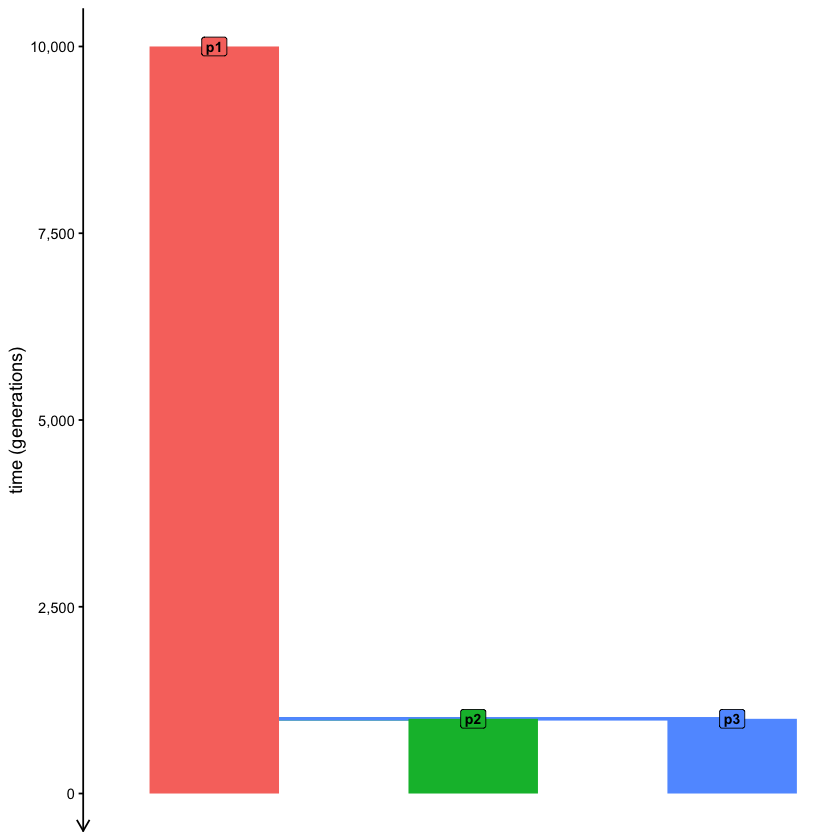

In [2]:
tsplit <- 1000

p1 <- population("p1", N = 1000, time = 10000)
p2 <- population("p2", N = 1000, time = tsplit, parent = p1)
p3 <- population("p3", N = 1000, time = tsplit, parent = p1)

model <- compile_model(list(p1, p2, p3), generation_time = 1)

plot_model(model, order = c("p1", "p2", "p3"), proportions = TRUE)

In [6]:
compute_outgroup_f3 <- function(tsplit) {
    p1 <- population("p1", N = 1000, time = 10000)
    p2 <- population("p2", N = 1000, time = tsplit, parent = p1)
    p3 <- population("p3", N = 1000, time = tsplit, parent = p1)
    
    model <- compile_model(list(p1, p2, p3), generation_time = 1)

    ts <- msprime(model, sequence_length = 10000000, recombination_rate = 1e-8) %>% ts_mutate(1e-8)
    samples <- ts_names(ts, split = "pop")
    
    ts_f3(ts, A = samples["p1"], B = samples["p2"], C = samples["p3"]) %>% mutate(tsplit = tsplit)
}

In [7]:
outgroup_f3 <- map_dfr(seq(500, 9000, by = 500), compute_outgroup_f3)

In [8]:
head(outgroup_f3)

A,B,C,f3,tsplit
<chr>,<chr>,<chr>,<dbl>,<dbl>
p1,p2,p3,4.321305e-06,500
p1,p2,p3,8.828159e-06,1000
p1,p2,p3,1.338284e-05,1500
p1,p2,p3,2.318505e-05,2000
p1,p2,p3,2.627328e-05,2500
p1,p2,p3,2.968803e-05,3000


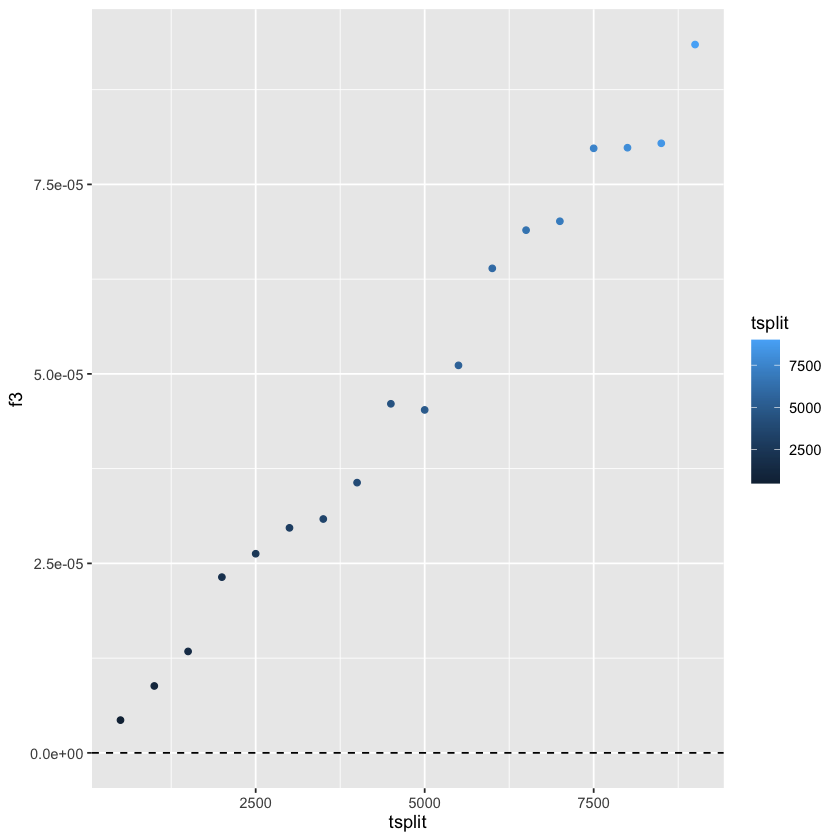

In [9]:
ggplot(outgroup_f3, aes(tsplit, f3, color = tsplit)) +
    geom_point() +
    geom_hline(yintercept = 0, linetype = "dashed")

# "Admixture" $f_3$

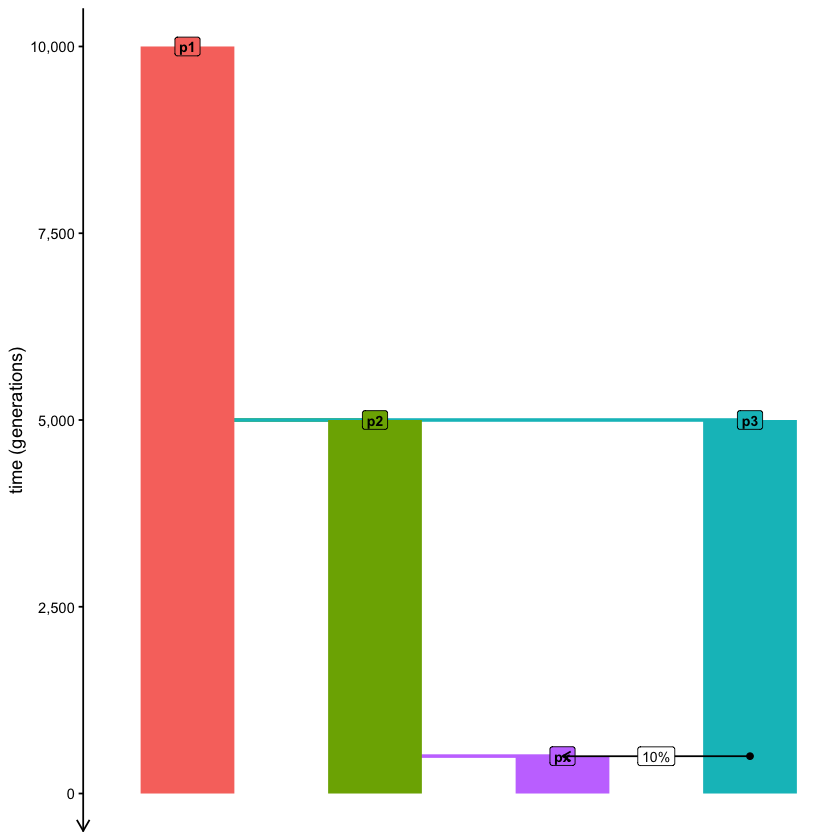

In [19]:
tsplit <- 500

p1 <- population("p1", N = 1000, time = 10000)
p2 <- population("p2", N = 1000, time = 5000, parent = p1)
p3 <- population("p3", N = 1000, time = 5000, parent = p1)
px <- population("px", N = 1000, time = tsplit + 1, parent = p2)
gf <- gene_flow(from = p3, to = px, start = tsplit, end = tsplit - 1, proportion = 0.1)

model <- compile_model(list(p1, p2, p3, px), gene_flow = gf, generation_time = 1)

plot_model(model, order = c("p1", "p2", "px", "p3"), proportions = TRUE)

In [34]:
compute_admix_f3 <- function(tmix) {    
    p1 <- population("p1", N = 1000, time = 10000)
    p2 <- population("p2", N = 1000, time = 5000, parent = p1)
    p3 <- population("p3", N = 1000, time = 5000, parent = p1)
    px <- population("px", N = 1000, time = tmix + 1, parent = p2)
    gf <- gene_flow(from = p3, to = px, start = tmix, end = tmix - 1, proportion = 0.1)
    
    model <- compile_model(list(p1, p2, p3, px), gene_flow = gf, generation_time = 1)

    ts <- msprime(model, sequence_length = 20000000, recombination_rate = 1e-8) %>% ts_mutate(1e-8)

    samples <- ts_names(ts, split = "pop")

    ts_f3(ts, A = samples["px"], B = samples["p1"], C = samples["p2"]) %>% mutate(tmix = tmix)
}

In [35]:
admix_f3 <- map_dfr(seq(50, tsplit, by = 10), compute_admix_f3)

In [36]:
head(admix_f3)

A,B,C,f3,tmix
<chr>,<chr>,<chr>,<dbl>,<dbl>
px,p1,p2,-3.318135e-06,50
px,p1,p2,-2.468135e-06,60
px,p1,p2,-1.566707e-06,70
px,p1,p2,-3.828374e-06,80
px,p1,p2,-2.959827e-06,90
px,p1,p2,-3.004784e-06,100


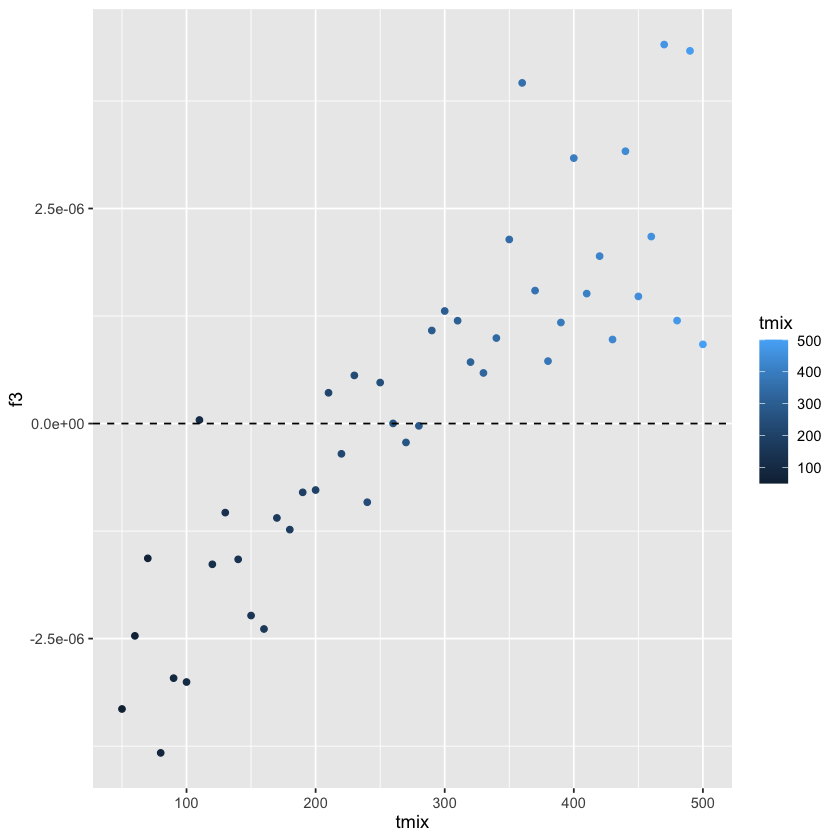

In [37]:
ggplot(admix_f3, aes(tmix, f3, color = tmix)) +
    geom_point() +
    geom_hline(yintercept = 0, linetype = "dashed")

# Exercises

- f3 losing power with drift in the admixed lineage (replicating Ben Peter's figure)
- amount of SNPs and amount of sequence vs Zscore & CI